In [39]:
import os
import re
import sys
import time
import getopt
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
sys.path.append("/home/users/mnergiz/softwares/licsar_extra/python")  # adjust as needed
import datetime as dt
from lics_tstools import load_licsbas_cumh5_as_xrda
from lics_tstools import generate_pmm_velocity
from lics_tstools import load_tif2xr

In [40]:
def da_to_xyz(da, out_path, varname=None):
    # Standardize coord names
    if "x" in da.dims: da = da.rename({"x": "lon"})
    if "y" in da.dims: da = da.rename({"y": "lat"})
    if "longitude" in da.dims: da = da.rename({"longitude": "lon"})
    if "latitude" in da.dims:  da = da.rename({"latitude":  "lat"})

    name = varname or (da.name if da.name else "z")
    da = da.rename(name)

    # Flatten -> DataFrame (lon, lat, value)
    df = (
        da.stack(pt=("lat", "lon"))
          .to_series()
          .dropna()
          .reset_index()
          .rename(columns={name: "value"})
          [ ["lon", "lat", "value"] ]
    )

    # Create parent dir only if one was provided
    parent = os.path.dirname(out_path)
    if parent:
        os.makedirs(parent, exist_ok=True)

    # Write XYZ (space-separated, no header)
    df.to_csv(out_path, sep=" ", header=False, index=False)


In [41]:
def _get_pixel_window(da, reference, halfwin=4):
    """
    Return a subset window around the nearest pixel to (lon, lat).

    halfwin=4 means:
      x: ix-4 ... ix+4
      y: iy-4 ... iy+4
    i.e. a 9x9 window.
    """
    lon0, lat0 = reference

    # nearest pixel index
    ix = int(np.abs(da.lon.values - lon0).argmin())
    iy = int(np.abs(da.lat.values - lat0).argmin())

    # clip to image boundaries
    x1 = max(0, ix - halfwin)
    x2 = min(da.sizes["lon"], ix + halfwin + 1)
    y1 = max(0, iy - halfwin)
    y2 = min(da.sizes["lat"], iy + halfwin + 1)

    return da.isel(lon=slice(x1, x2), lat=slice(y1, y2))


def spatial_reference_2d(da, reference, use_nearest=False, halfwin=4):
    """
    Spatially reference a 2D DataArray (lat, lon) to a point
    or to the mean of a pixel window around that point.

    Parameters
    ----------
    da : xarray.DataArray
        2D array with dims (lat, lon)
    reference : tuple
        (lon, lat)
    use_nearest : bool
        If True, use nearest single pixel.
        If False, use mean over window defined by halfwin.
    halfwin : int
        Half window size in pixels. halfwin=4 => 9x9 window.
    """
    da = da.where(da != 0)

    if use_nearest:
        ref_val = da.sel(lon=reference[0], lat=reference[1], method="nearest")
    else:
        ref_win = _get_pixel_window(da, reference, halfwin=halfwin)
        ref_val = ref_win.mean(dim=("lat", "lon"), skipna=True)

    if np.isnan(ref_val.values):
        ref_val = da.sel(lon=reference[0], lat=reference[1], method="nearest")

    return da - ref_val


def reference_ts_dataset(ds, reference, vars_to_ref=None, use_nearest=False, halfwin=4, verbose=True):

    if vars_to_ref is None:
        vars_to_ref = ["cum", "iono", "tide", "sltd"]

    ds_ref = ds.copy()

    for v in vars_to_ref:
        if v not in ds.data_vars:
            if verbose:
                print(f"Skipping '{v}': not found in dataset")
            continue

        da = ds[v]

        # ensure required dims exist
        if not {"time","lat","lon"}.issubset(da.dims):
            if verbose:
                print(f"Skipping '{v}': dims are {da.dims}")
            continue

        # 1) temporal reference
        da_tref = da - da.isel(time=0)

        if use_nearest:

            ref_ts = da_tref.sel(
                lon=reference[0],
                lat=reference[1],
                method="nearest"
            )

        else:
            # find nearest pixel index
            ix = int(np.abs(da.lon.values - reference[0]).argmin())
            iy = int(np.abs(da.lat.values - reference[1]).argmin())

            x1 = max(0, ix-halfwin)
            x2 = min(da.sizes["lon"], ix+halfwin+1)
            y1 = max(0, iy-halfwin)
            y2 = min(da.sizes["lat"], iy+halfwin+1)

            # extract window for all times
            ref_win = da_tref.isel(lon=slice(x1,x2), lat=slice(y1,y2))

            # average window → reference time series
            ref_ts = ref_win.mean(dim=("lat","lon"), skipna=True)

        ds_ref[v] = da_tref - ref_ts

        if verbose:
            if use_nearest:
                print(f"Referenced '{v}' using nearest pixel")
            else:
                print(f"Referenced '{v}' using ±{halfwin} pixel window")

    return ds_ref

def extract_ts_window_mean(da, point, halfwin=4):
    """
    Extract a time series from a (time, lat, lon) DataArray
    using the mean of a window around the nearest pixel to point.

    Parameters
    ----------
    da : xarray.DataArray
        Must have dims including (time, lat, lon)
    point : tuple
        (lon, lat)
    halfwin : int
        Half window size in pixels. halfwin=4 => 9x9 window

    Returns
    -------
    ts : xarray.DataArray
        1D time series
    """
    ix = int(np.abs(da.lon.values - point[0]).argmin())
    iy = int(np.abs(da.lat.values - point[1]).argmin())

    x1 = max(0, ix - halfwin)
    x2 = min(da.sizes["lon"], ix + halfwin + 1)
    y1 = max(0, iy - halfwin)
    y2 = min(da.sizes["lat"], iy + halfwin + 1)

    win = da.isel(lon=slice(x1, x2), lat=slice(y1, y2))
    ts = win.mean(dim=("lat", "lon"), skipna=True)

    return ts

In [65]:
frame="021D_05266_252525"
sbovl=True
if sbovl:
    path=f"/gws/ssde/j25a/nceo_geohazards/vol2/LiCS/temp/insar_proc/mnergizci/1.postseismic_dataset_backup_04122025/sbois/{frame}"
else:
    path=f"/gws/ssde/j25a/nceo_geohazards/vol2/LiCS/temp/insar_proc/mnergizci/1.postseismic_dataset_backup_04122025/ranges/{frame}"
TS_folder = next(
    p for p in Path(path).iterdir()
    if p.is_dir() and p.name.startswith("TS_")
)
GEOC_folder = os.path.join(os.path.dirname(os.path.normpath(TS_folder)), "GEOCml10GACOS")
os.environ["LiCSAR_public"] = "/gws/ssde/j25a/nceo_geohazards/vol1/public/LiCSAR_products.public/"
cumfile=f"{TS_folder}/cum.h5"
cumfiltfile=f"{TS_folder}/cum_filt.h5"
cum = load_licsbas_cumh5_as_xrda(cumfile)
cum_filt = load_licsbas_cumh5_as_xrda(cumfiltfile)

#plotting and reference points
if sbovl:
    reference=(37, 35.55) #lon lat
    point1=(37.55, 38.55) #lon lat
else:
    reference=(37, 35.5) #lon lat
    point1=(36.7, 38.2) #lon lat

#years calculation
years = (cum.time[-1] - cum.time[0]) / np.timedelta64(1, 'D') / 365.25
print(float(years))

1.8726899383983573


In [52]:
if sbovl:
    vars_to_ref = ["cum", "iono", "tide"]
else:
    vars_to_ref = ["cum", "iono", "tide", "sltd"]

cum_ref = reference_ts_dataset(
    cum,
    reference=reference,
    vars_to_ref=vars_to_ref,
    use_nearest=False,
    halfwin=4,
    verbose=True
)

cum_filt_ref = reference_ts_dataset(
    cum_filt,
    reference=reference,
    vars_to_ref=vars_to_ref,
    use_nearest=False,
    halfwin=4,
    verbose=True
)

Referenced 'cum' using ±4 pixel window
Referenced 'iono' using ±4 pixel window
Referenced 'tide' using ±4 pixel window
Referenced 'sltd' using ±4 pixel window
Referenced 'cum' using ±4 pixel window
Skipping 'iono': not found in dataset
Skipping 'tide': not found in dataset
Skipping 'sltd': not found in dataset


In [66]:
##plate motion and interseismic effect
#plate motion
vlos_eurasia = generate_pmm_velocity(frame, 'Eurasia', 'GEOC', azi=sbovl)
# #reshape
vlos_eurasia_reshaped=vlos_eurasia.interp_like(cum.vel)
plate_motion_cumulative = vlos_eurasia_reshaped * years

#interseismic model
ve_gnss_nc='/gws/ssde/j25a/nceo_geohazards/vol1/projects/COMET/mnergizci/1.second_paper/interseismic/decomp3d.nc'
vn_gnss_nc='/gws/ssde/j25a/nceo_geohazards/vol1/projects/COMET/mnergizci/1.second_paper/interseismic/velmap_insars29_sbois0_scalar.nc'

#ENU unit vectors
if sbovl:
    E_unit=load_tif2xr(f'{path}/{frame}.E.azi.geo.tif')
    N_unit=load_tif2xr(f'{path}/{frame}.N.azi.geo.tif')
    # azimuth has no vertical sensitivity
    U_unit = xr.zeros_like(E_unit)
else:
    E_unit=load_tif2xr(f'{path}/{frame}.E.geo.tif')
    N_unit=load_tif2xr(f'{path}/{frame}.N.geo.tif')
    U_unit=load_tif2xr(f'{path}/{frame}.U.geo.tif')

#load interseismic model
ve_gnss= xr.load_dataset(ve_gnss_nc).Ve
vn_gnss= xr.load_dataset(vn_gnss_nc).Vn

##reshape
ve_gnss_reshaped=ve_gnss.interp_like(E_unit)
vn_gnss_reshaped=vn_gnss.interp_like(E_unit)

interseismic_velo = ve_gnss_reshaped * E_unit + vn_gnss_reshaped * N_unit
interseismic_velo_cumulative = interseismic_velo*years

##reference
plate_motion_cumulative_ref = spatial_reference_2d(
    plate_motion_cumulative, reference, use_nearest=False
)
plate_motion_cumulative_ref=plate_motion_cumulative_ref.interp_like(E_unit)


interseismic_velo_cumulative_ref = spatial_reference_2d(
    interseismic_velo_cumulative, reference, use_nearest=False
)
interseismic_velo_cumulative_ref=interseismic_velo_cumulative_ref.interp_like(E_unit)


assume a spheroidal Earth as defined in WGS84
Interpolating the plate velocity ENU vectors to the original frame resolution
Calculating the plate motion velocity in LOS (please check the sign here)


In [ ]:
interseismic_velo = ve_gnss_reshaped * E_unit + vn_gnss_reshaped * N_unit

In [54]:
if sbovl:
    uncorrected_cum = (
        cum_filt_ref.cum.isel(time=-1)
        + plate_motion_cumulative_ref.interp_like(cum_filt_ref.cum.isel(time=-1))
        + interseismic_velo_cumulative_ref.interp_like(cum_filt_ref.cum.isel(time=-1))
        + cum_ref.iono.isel(time=-1).interp_like(cum_filt_ref.cum.isel(time=-1))
        + cum_ref.tide.isel(time=-1).interp_like(cum_filt_ref.cum.isel(time=-1))    
    )
else:
    uncorrected_cum = (
        cum_filt_ref.cum.isel(time=-1)
        + plate_motion_cumulative_ref.interp_like(cum_filt_ref.cum.isel(time=-1))
        + interseismic_velo_cumulative_ref.interp_like(cum_filt_ref.cum.isel(time=-1))
        + cum_ref.iono.isel(time=-1).interp_like(cum_filt_ref.cum.isel(time=-1))
        + cum_ref.tide.isel(time=-1).interp_like(cum_filt_ref.cum.isel(time=-1))
        + cum_ref.sltd.isel(time=-1).interp_like(cum_filt_ref.cum.isel(time=-1))
    )
corrected_cum=cum_filt_ref.cum[-1]
iono=cum_ref.iono[-1]
tide=cum_ref.tide[-1]
if sbovl == False:
    topog=cum_ref.sltd[-1]

DEM already exists!


getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names


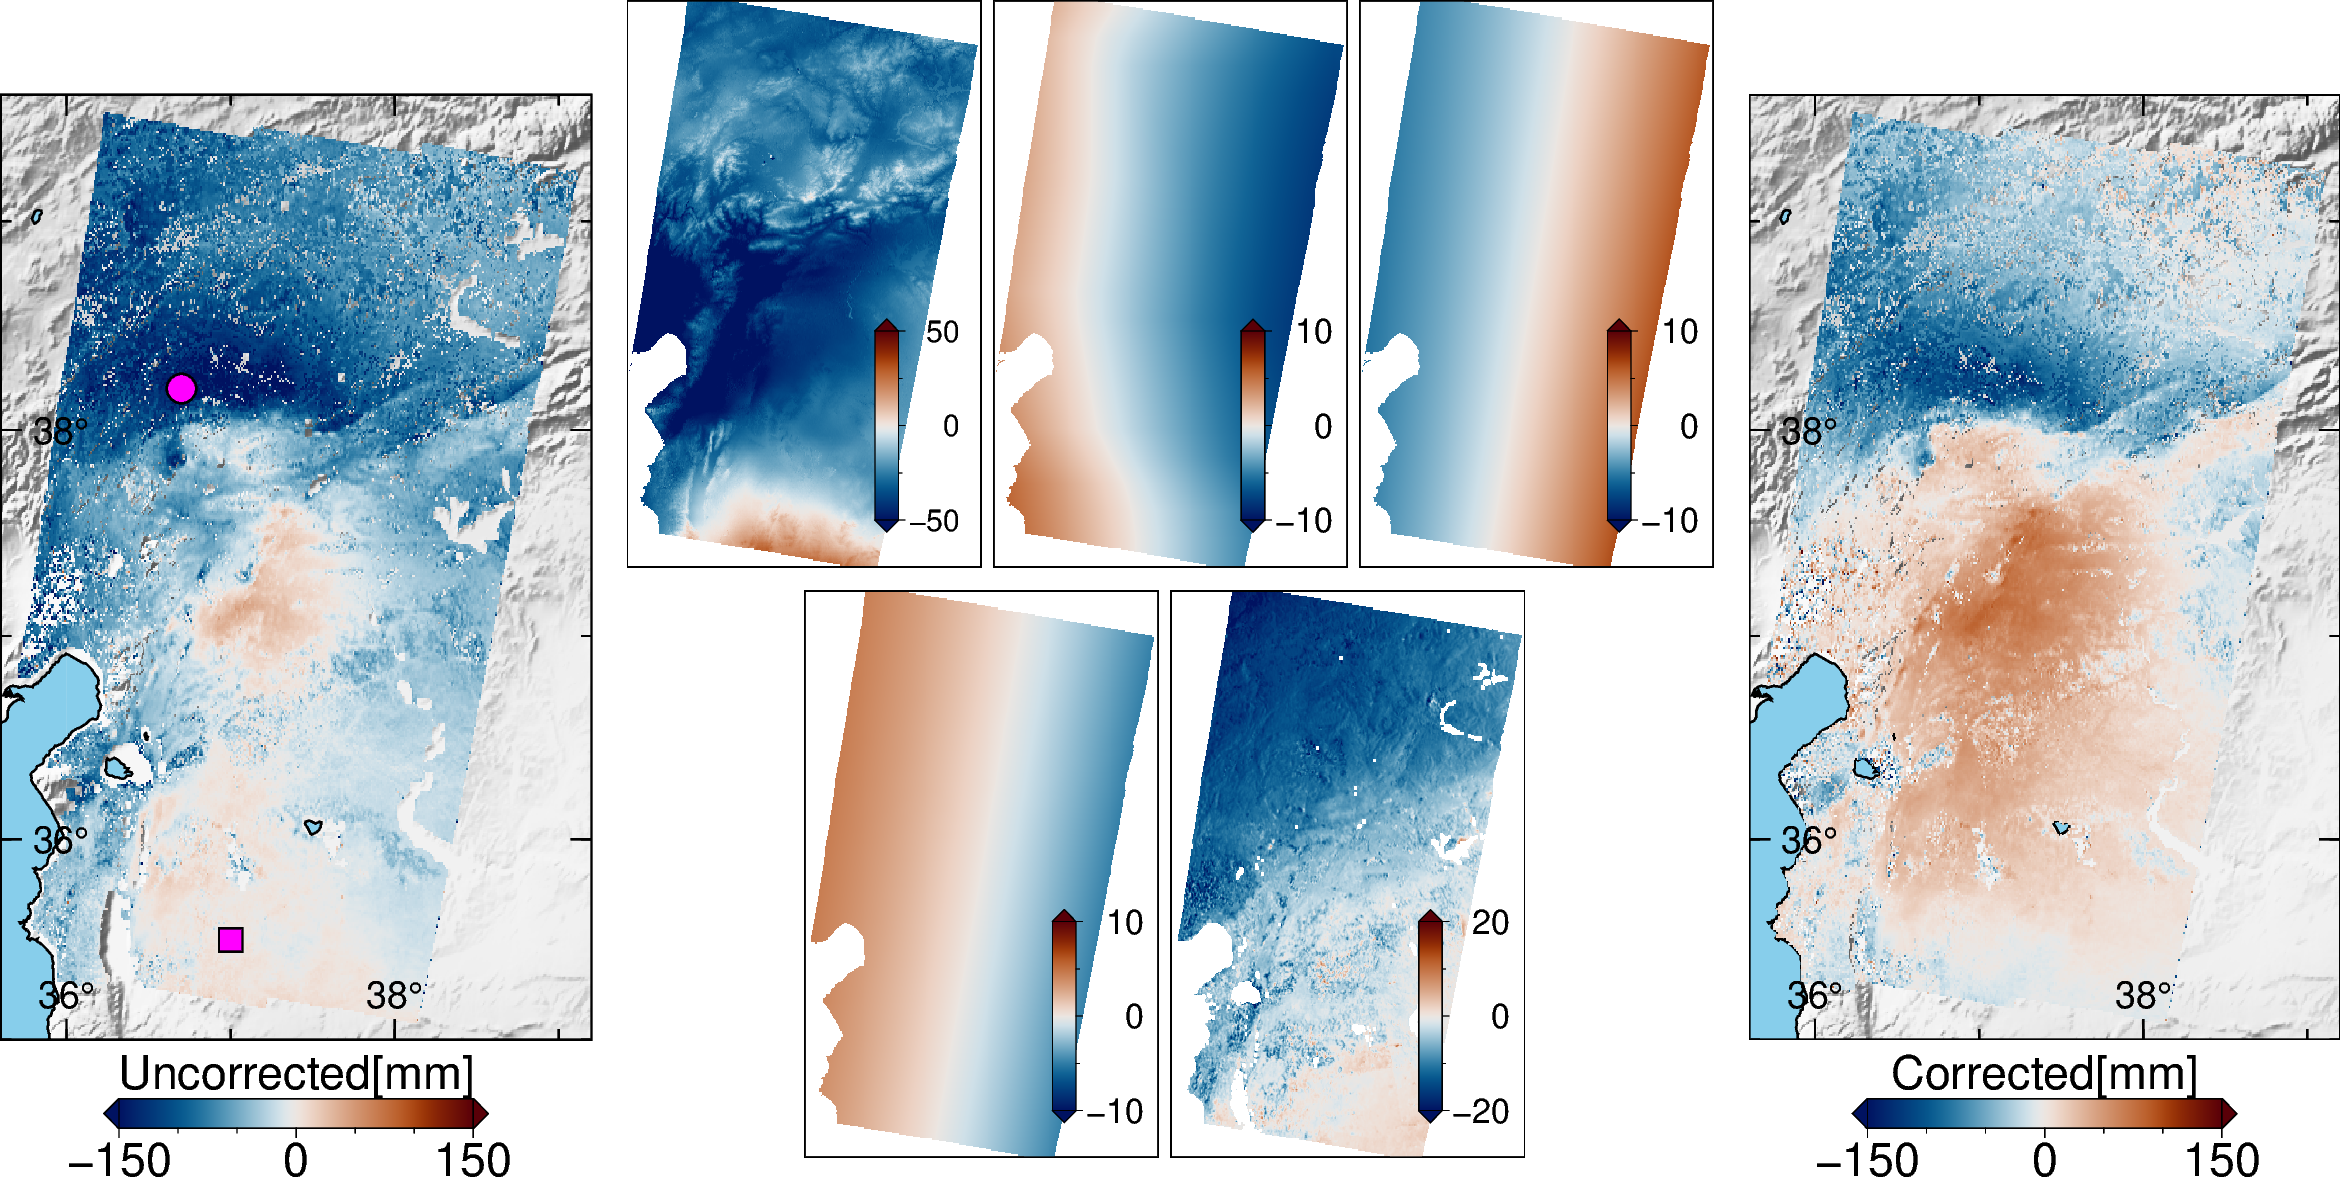

In [55]:
import pygmt
##DEM file
dem_file='earth_relief_fullAHB_30s.nc'
batchdir = os.environ.get("BATCH_CACHE_DIR")
dem = os.path.join(batchdir, dem_file)
#####
# DEM downloading
if not os.path.exists(dem):
    print('DEM is downloading please wait! After downloading, the process will be faster!')
    try:
        lonmin_lamb = 1  # degrees East
        lonmax_lamb = 80
        latmin_lamb = 25
        latmax_lamb = 60
        RR_used = [lonmin_lamb, lonmax_lamb, latmin_lamb, latmax_lamb]
        dem_resolution='30s'
        # Download the earth relief data and save it to a file
        grid = pygmt.datasets.load_earth_relief(resolution=dem_resolution, region=RR_used)
        # Saving the grid to a NetCDF file
        grid.to_netcdf(dem)
        print(f"Data successfully downloaded and saved to {dem}")
    except Exception as e:
        print(f"An error occurred: {e}")
else:
    print(f'DEM already exists!')

##fault file
# GEMS_dir='/scratch/eemne/GEMS'
# fault_file=f'{GEMS_dir}/actives/TR_active_faults.shp'

#plot region
if sbovl:
    plot_region = [35.4, 39.2, 35, 39.6]
else:
    plot_region = [35.6, 39.2, 35, 39.6]
#####
fig = pygmt.Figure()
pygmt.config(
    MAP_FRAME_TYPE="plain",
    FONT_ANNOT_PRIMARY="20p,Helvetica,black",   # longitude ticks
    FONT_LABEL="20p,Helvetica,black",       # axis labels
    FORMAT_GEO_MAP='D',
    MAP_FRAME_PEN="0.5p,black",  # 2-point thick black frame line
    MAP_DEFAULT_PEN="0.5p,black",
    # MAP_TICK_PEN_PRIMARY="1p",
    # MAP_TICK_LENGTH_PRIMARY="5p",
    MAP_TICK_LENGTH="5p"
)

if sbovl:
    ## Figure a --plotting Uncorrected deformation
    #Plot background DEM
    fig.basemap(projection="M5c", region=plot_region, frame=['WSne'])
    pygmt.makecpt(cmap="gray", series=[-200, 10000, 3000], continuous=True, reverse=True)
    fig.grdimage(grid=dem,cmap=True,region=plot_region,shading=True,frame=False)
    fig.coast(shorelines="black", water="skyblue")
    #plotting uncorrected deformation
    cmap = pygmt.makecpt(cmap="vik", series=[-150, 150, 1], continuous=True)
    Vn_xyz='temp_Vn.xyz'
    da_to_xyz(uncorrected_cum, Vn_xyz,varname="Vn")
    fig.plot(data=Vn_xyz, style="c0.03c", fill="+z", cmap=True)
    os.remove(Vn_xyz)

    ###colorbar
    pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT_PRIMARY="25p,Helvetica,black", FONT_LABEL="25p,Helvetica, black")
    fig.colorbar(
        frame='a150f50+lUncorrected[mm]',  # Label for the color bar
        cmap=True,
        position="JBC+o0c/0.5c+w3c/0.25c+ml+h+e"
        # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
        # box="+gwhite@50"
    )

    # plotting reference points
    # circle for point1
    fig.plot(
        x=point1[0],
        y=point1[1],
        style="c0.25c",      # circle, diameter 0.25 cm
        fill="magenta1",
        pen="0.5p,black"
    )

    # rectangle for reference point
    fig.plot(
        x=reference[0],
        y=reference[1],
        style="r0.20c/0.20c",  # rectangle width/height
        fill="magenta1",
        pen="0.5p,black"
    )

    #last basemap
    pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT="9p,Helvetica,black")
    fig.basemap(projection="M5c", region=plot_region, frame=["x2f1","y2f1",'WSne'])


    #Figure b --plotting iono
    fig.shift_origin(xshift='5.3c', yshift='4c')
    #Plot background DEM
    fig.basemap(projection="M3c", region=plot_region, frame=['wsne'])
    #plotting uncorrected deformation
    cmap = pygmt.makecpt(cmap="vik", series=[-20, 20, 1], continuous=True)
    fig.grdimage(grid=iono, cmap=cmap, region=plot_region, nan_transparent=True)

    ###colorbar
    pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT_PRIMARY="22p,Helvetica,black", FONT_LABEL="20p,Helvetica, black")
    fig.colorbar(
        frame='a20f10',  # Label for the color bar
        cmap=True,
        position="JMR+o-0.9c/-1.2c+w1.6c/0.2c+ml+e"
        # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
        # box="+gwhite@50"
    )

    #last basemap
    pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT="9p,Helvetica,black")
    fig.basemap(projection="M3c", region=plot_region, frame=["x200f100","y200f100",'WSne'])


    #Figure c --plotting tide
    fig.shift_origin(xshift='3.1c')
    #Plot background DEM
    fig.basemap(projection="M3c", region=plot_region, frame=['wsne'])
    #plotting uncorrected deformation
    cmap = pygmt.makecpt(cmap="vik", series=[-5, 5, 1], continuous=True)
    fig.grdimage(grid=tide, cmap=cmap, region=plot_region, nan_transparent=True)

    ###colorbar
    pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT_PRIMARY="25p,Helvetica,black", FONT_LABEL="25p,Helvetica, black")
    fig.colorbar(
        frame='a5f2.5',  # Label for the color bar
        cmap=True,
        position="JMR+o-0.9c/-1.2c+w1.6c/0.2c+ml+e"
        # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
        # box="+gwhite@50"
    )

    #last basemap
    pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT="9p,Helvetica,black")
    fig.basemap(projection="M3c", region=plot_region, frame=["x200f100","y200f100",'WSne'])


    #Figure d --plotting plate
    fig.shift_origin(xshift='-3.1c',  yshift='-4.7c')
    #Plot background DEM
    fig.basemap(projection="M3c", region=plot_region, frame=['wsne'])
    #plotting uncorrected deformation
    cmap = pygmt.makecpt(cmap="vik", series=[-2, 2, 1], continuous=True)
    fig.grdimage(grid=plate_motion_cumulative_ref, cmap=cmap, region=plot_region, nan_transparent=True)

    ###colorbar
    pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT_PRIMARY="25p,Helvetica,black", FONT_LABEL="25p,Helvetica, black")
    fig.colorbar(
        frame='a2f1',  # Label for the color bar
        cmap=True,
        position="JMR+o-0.9c/-1.2c+w1.6c/0.2c+ml+e"
        # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
        # box="+gwhite@50"
    )

    #last basemap
    pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT="9p,Helvetica,black")
    fig.basemap(projection="M3c", region=plot_region, frame=["x200f100","y200f100",'WSne'])

    #Figure e --plotting interseismic
    fig.shift_origin(xshift='3.1c')
    #Plot background DEM
    fig.basemap(projection="M3c", region=plot_region, frame=['wsne'])
    #plotting uncorrected deformation
    cmap = pygmt.makecpt(cmap="vik", series=[-20, 20, 1], continuous=True)
    fig.grdimage(grid=interseismic_velo_cumulative_ref, cmap=cmap, region=plot_region, nan_transparent=True)

    ###colorbar
    pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT_PRIMARY="25p,Helvetica,black", FONT_LABEL="25p,Helvetica, black")
    fig.colorbar(
        frame='a20f10',  # Label for the color bar
        cmap=True,
        position="JMR+o-0.9c/-1.2c+w1.6c/0.2c+ml+e"
        # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
        # box="+gwhite@50"
    )

    #last basemap
    pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT="9p,Helvetica,black")
    fig.basemap(projection="M3c", region=plot_region, frame=["x200f100","y200f100",'WSne'])


    #Figure f --plotting plate
    fig.shift_origin(xshift='3.3c',  yshift='0.7c')
    fig.basemap(projection="M5c", region=plot_region, frame=['WSne'])
    pygmt.makecpt(cmap="gray", series=[-200, 10000, 3000], continuous=True, reverse=True)
    fig.grdimage(grid=dem,cmap=True,region=plot_region,shading=True,frame=False)
    fig.coast(shorelines="black", water="skyblue")
    #plotting uncorrected deformation
    cmap = pygmt.makecpt(cmap="vik", series=[-150, 150, 1], continuous=True)
    Vn_xyz='temp_Vn.xyz'
    da_to_xyz(corrected_cum, Vn_xyz,varname="Vn")
    fig.plot(data=Vn_xyz, style="c0.03c", fill="+z", cmap=True)
    os.remove(Vn_xyz)

    ###colorbar
    pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT_PRIMARY="25p,Helvetica,black", FONT_LABEL="25p,Helvetica, black")
    fig.colorbar(
        frame='a150f50+lCorrected[mm]',  # Label for the color bar
        cmap=True,
        position="JBC+o0c/0.5c+w3c/0.25c+ml+h+e"
        # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
        # box="+gwhite@50"
    )

    #last basemap
    pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT="9p,Helvetica,black")
    fig.basemap(projection="M5c", region=plot_region, frame=["x2f1","y2f1",'WSne'])



    fig.savefig("Figure3_cumulative_corrections_sboi_raw.png")
else:
    ## Figure a --plotting Uncorrected deformation
    #Plot background DEM
    fig.basemap(projection="M5c", region=plot_region, frame=['WSne'])
    pygmt.makecpt(cmap="gray", series=[-200, 10000, 3000], continuous=True, reverse=True)
    fig.grdimage(grid=dem,cmap=True,region=plot_region,shading=True,frame=False)
    fig.coast(shorelines="black", water="skyblue")
    #plotting uncorrected deformation
    cmap = pygmt.makecpt(cmap="vik", series=[-150, 150, 1], continuous=True)
    fig.grdimage(grid=uncorrected_cum, cmap=cmap, region=plot_region, nan_transparent=True)

    ###colorbar
    pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT_PRIMARY="25p,Helvetica,black", FONT_LABEL="25p,Helvetica, black")
    fig.colorbar(
        frame='a150f50+lUncorrected[mm]',  # Label for the color bar
        cmap=True,
        position="JBC+o0c/0.5c+w3c/0.25c+ml+h+e"
        # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
        # box="+gwhite@50"
    )

    # plotting reference points
    # circle for point1
    fig.plot(
        x=point1[0],
        y=point1[1],
        style="c0.25c",      # circle, diameter 0.25 cm
        fill="magenta1",
        pen="0.5p,black"
    )

    # rectangle for reference point
    fig.plot(
        x=reference[0],
        y=reference[1],
        style="r0.20c/0.20c",  # rectangle width/height
        fill="magenta1",
        pen="0.5p,black"
    )

    #last basemap
    pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT="9p,Helvetica,black")
    fig.basemap(projection="M5c", region=plot_region, frame=["x2f1","y2f1",'WSne'])

    #Figure b --plotting troposhere
    fig.shift_origin(xshift='5.3c', yshift='4c')
    #Plot background DEM
    fig.basemap(projection="M3c", region=plot_region, frame=['wsne'])
    #plotting uncorrected deformation
    cmap = pygmt.makecpt(cmap="vik", series=[-50, 50, 1], continuous=True)
    fig.grdimage(grid=topog, cmap=cmap, region=plot_region, nan_transparent=True)

    ###colorbar
    pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT_PRIMARY="22p,Helvetica,black", FONT_LABEL="20p,Helvetica, black")
    fig.colorbar(
        frame='a50f25',  # Label for the color bar
        cmap=True,
        position="JMR+o-0.9c/-1.2c+w1.6c/0.2c+ml+e"
        # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
        # box="+gwhite@50"
    )

    #last basemap
    pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT="9p,Helvetica,black")
    fig.basemap(projection="M3c", region=plot_region, frame=["x200f100","y200f100",'WSne'])

    #Figure c --plotting iono
    fig.shift_origin(xshift='3.1c')
    #Plot background DEM
    fig.basemap(projection="M3c", region=plot_region, frame=['wsne'])
    #plotting uncorrected deformation
    cmap = pygmt.makecpt(cmap="vik", series=[-10, 10, 1], continuous=True)
    fig.grdimage(grid=iono, cmap=cmap, region=plot_region, nan_transparent=True)

    ###colorbar
    pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT_PRIMARY="25p,Helvetica,black", FONT_LABEL="25p,Helvetica, black")
    fig.colorbar(
        frame='a10f5',  # Label for the color bar
        cmap=True,
        position="JMR+o-0.9c/-1.2c+w1.6c/0.2c+ml+e"
        # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
        # box="+gwhite@50"
    )

    #last basemap
    pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT="9p,Helvetica,black")
    fig.basemap(projection="M3c", region=plot_region, frame=["x200f100","y200f100",'WSne'])

    #Figure d --plotting tide
    fig.shift_origin(xshift='3.1c')
    #Plot background DEM
    fig.basemap(projection="M3c", region=plot_region, frame=['wsne'])
    #plotting uncorrected deformation
    cmap = pygmt.makecpt(cmap="vik", series=[-10, 10, 1], continuous=True)
    fig.grdimage(grid=tide, cmap=cmap, region=plot_region, nan_transparent=True)

    ###colorbar
    pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT_PRIMARY="25p,Helvetica,black", FONT_LABEL="25p,Helvetica, black")
    fig.colorbar(
        frame='a10f5',  # Label for the color bar
        cmap=True,
        position="JMR+o-0.9c/-1.2c+w1.6c/0.2c+ml+e"
        # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
        # box="+gwhite@50"
    )

    #last basemap
    pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT="9p,Helvetica,black")
    fig.basemap(projection="M3c", region=plot_region, frame=["x200f100","y200f100",'WSne'])

    #Figure e --plate tide
    fig.shift_origin(xshift='-4.7c', yshift='-5c')
    #Plot background DEM
    fig.basemap(projection="M3c", region=plot_region, frame=['wsne'])
    #plotting uncorrected deformation
    cmap = pygmt.makecpt(cmap="vik", series=[-10, 10, 1], continuous=True)
    fig.grdimage(grid=plate_motion_cumulative_ref , cmap=cmap, region=plot_region, nan_transparent=True)

    ###colorbar
    pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT_PRIMARY="25p,Helvetica,black", FONT_LABEL="25p,Helvetica, black")
    fig.colorbar(
        frame='a10f5',  # Label for the color bar
        cmap=True,
        position="JMR+o-0.9c/-1.2c+w1.6c/0.2c+ml+e"
        # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
        # box="+gwhite@50"
    )

    #last basemap
    pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT="9p,Helvetica,black")
    fig.basemap(projection="M3c", region=plot_region, frame=["x200f100","y200f100",'WSne'])

    #Figure f --interseismic
    fig.shift_origin(xshift='3.1c')
    #Plot background DEM
    fig.basemap(projection="M3c", region=plot_region, frame=['wsne'])
    #plotting uncorrected deformation
    cmap = pygmt.makecpt(cmap="vik", series=[-20, 20, 1], continuous=True)
    fig.grdimage(grid=interseismic_velo_cumulative_ref , cmap=cmap, region=plot_region, nan_transparent=True)

    ###colorbar
    pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT_PRIMARY="25p,Helvetica,black", FONT_LABEL="25p,Helvetica, black")
    fig.colorbar(
        frame='a20f10',  # Label for the color bar
        cmap=True,
        position="JMR+o-0.9c/-1.2c+w1.6c/0.2c+ml+e"
        # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
        # box="+gwhite@50"
    )

    #last basemap
    pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT="9p,Helvetica,black")
    fig.basemap(projection="M3c", region=plot_region, frame=["x200f100","y200f100",'WSne'])

    #Figure g --corrected
    fig.shift_origin(xshift='4.9c', yshift="1c")
    #Plot background DEM
    fig.basemap(projection="M5c", region=plot_region, frame=['WSne'])
    pygmt.makecpt(cmap="gray", series=[-200, 10000, 3000], continuous=True, reverse=True)
    fig.grdimage(grid=dem,cmap=True,region=plot_region,shading=True,frame=False)
    fig.coast(shorelines="black", water="skyblue")
    #plotting uncorrected deformation
    cmap = pygmt.makecpt(cmap="vik", series=[-150, 150, 1], continuous=True)
    fig.grdimage(grid=corrected_cum , cmap=cmap, region=plot_region, nan_transparent=True)

    ###colorbar
    pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT_PRIMARY="25p,Helvetica,black", FONT_LABEL="25p,Helvetica, black")
    fig.colorbar(
        frame='a150f50+lCorrected[mm]',  # Label for the color bar
        cmap=True,
        position="JBC+o0c/0.5c+w3c/0.25c+ml+h+e"
        # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
        # box="+gwhite@50"
    )

    #last basemap
    pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT="9p,Helvetica,black")
    fig.basemap(projection="M5c", region=plot_region, frame=["x2f1","y2f1",'WSne'])


    fig.savefig("Figure3_cumulative_corrections_range_raw.png")


fig.show()


In [56]:
# extract time series at point1 using ±4 pixels
tide_ts = extract_ts_window_mean(cum_ref["tide"], point1, halfwin=4)
iono_ts = extract_ts_window_mean(cum_ref["iono"], point1, halfwin=4)
cum_ts  = extract_ts_window_mean(cum_ref["cum"],  point1, halfwin=4)
cum_filt_ts = extract_ts_window_mean(cum_filt_ref["cum"], point1, halfwin=4)
time = cum_ref.time
if sbovl == False:
    sltd_ts = extract_ts_window_mean(cum_ref["sltd"], point1, halfwin=4)


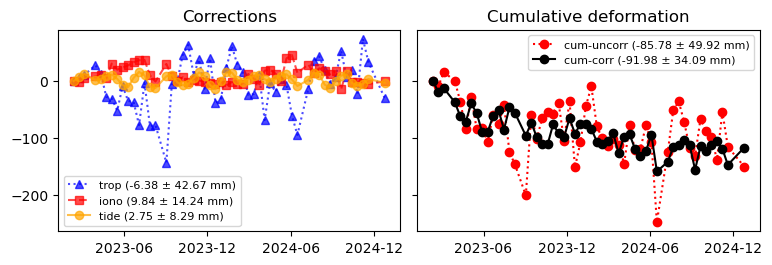

In [57]:

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# plt.rcParams.update({
#     "font.family": "serif",
#     "font.serif": ["Times New Roman"],   # common journal style
#     "font.size": 9,                      # base size
#     "axes.labelsize": 9,
#     "axes.titlesize": 10,
#     "xtick.labelsize": 8,
#     "ytick.labelsize": 8,
#     "legend.fontsize": 8,
#     "axes.linewidth": 0.8,
#     "lines.linewidth": 1.2,
#     "lines.markersize": 4,
# })

cm = 1 / 2.54  # inches per cm

fig, ax = plt.subplots(1, 2, figsize=(20*cm, 7*cm), sharex=True, sharey=True)

##statistics
#mean
if sbovl:
    uncor_cum_ts = cum_ts + tide_ts + iono_ts
else:
    uncor_cum_ts = cum_ts + tide_ts + iono_ts + sltd_ts
    mean_trop = np.nanmean(sltd_ts)
    std_trop = np.nanstd(sltd_ts)
    
#mean
mean_iono = np.nanmean(iono_ts)
mean_tide = np.nanmean(tide_ts)
mean_uncor_cum = np.nanmean(uncor_cum_ts)
mean_cum = np.nanmean(cum_ts)
#std
std_iono = np.nanstd(iono_ts)
std_tide = np.nanstd(tide_ts)
std_uncor_cum = np.nanstd(uncor_cum_ts)
std_cum = np.nanstd(cum_ts)



# ---- Left panel: corrections ----
plt.rcParams["legend.fontsize"] = 8
if sbovl==False:
    ax[0].plot(time, sltd_ts, color="blue", marker="^", linestyle=":", alpha=0.7, label=f"trop ({mean_trop:.2f} ± {std_trop:.2f} mm)")
ax[0].plot(time, iono_ts, color="red", marker="s", linestyle="--", alpha=0.7, label=f"iono ({mean_iono:.2f} ± {std_iono:.2f} mm)")
ax[0].plot(time, tide_ts, color="orange", marker="o", linestyle="-", alpha=0.7, label=f"tide ({mean_tide:.2f} ± {std_tide:.2f} mm)")

# ax[0].set_ylabel("Displacement (mm)")
ax[0].set_title("Corrections")
ax[0].legend()

# ---- Right panel: cumulative deformation ----
ax[1].plot(time, uncor_cum_ts, color="red", marker="o", linestyle=":", label=f"cum-uncorr ({mean_uncor_cum:.2f} ± {std_uncor_cum:.2f} mm)")
ax[1].plot(time, cum_ts, color="black", marker="o", linestyle="-", label=f"cum-corr ({mean_cum:.2f} ± {std_cum:.2f} mm)")

ax[1].set_title("Cumulative deformation")
ax[1].legend()

# hide y tick labels on second plot
ax[1].tick_params(labelleft=False)

# ----- Sparse x-axis ticks -----
locator = mdates.MonthLocator(interval=6)   # every 3 months
formatter = mdates.DateFormatter('%Y-%m')

for a in ax:
    a.xaxis.set_major_locator(locator)
    a.xaxis.set_major_formatter(formatter)

# # shared x label
# fig.supxlabel("Time")

plt.tight_layout()
# reduce space between panels
fig.subplots_adjust(wspace=0.05)
if sbovl==False:
    plt.savefig("Figure3_cumulative_corrections_range_raw_time_series.png", dpi=300)
else:
    plt.savefig("Figure3_cumulative_corrections_sboi_raw_time_series.png", dpi=300)
plt.show()